# DM1580 Project  
# Build and Explore a Video Compression System

This is the **2026 version** of the project notebook.

It is designed to be:
- conceptually rigorous
- clearly scaffolded
- coherent as a single project
- realistic for students to complete
- easy to supervise and assess

This project is graded **Pass / Fail**.

## Project overview

In this project, you will design, implement, and evaluate a simplified video compression system.

The goal is not only to make a pipeline run, but to understand how a compression system works as a sequence of representations and decisions:

- an image becomes a signal
- a signal is transformed into coefficients
- coefficients are quantized and coded
- temporal redundancy is exploited through prediction
- quality, rate, and complexity must be balanced

You will first build a basic intraframe codec, then extend it to predictive coding, and finally evaluate the system on a full video sequence.

## Deliverables

You must submit **one single Jupyter notebook** containing:

### A. System implementation
Your complete codec pipeline.

### B. Results
Visual and numerical outputs from the pipeline.

### C. Experiments
At least two required experiments.

### D. Analysis
Short written answers interpreting your results.

### E. Individual reflection
A short personal reflection from each student.

Your notebook must be:
- self-contained
- clearly structured
- executable from start to finish
- understandable to a reader

## Minimum working system

To pass, your project must include at least the following:

### Stage 1
A working intraframe codec on one frame:
- RGB → Y
- 8×8 block splitting
- DCT
- quantization
- Huffman coding of quantized DCT coefficients
- inverse quantization
- inverse DCT
- reconstruction
- PSNR

### Stage 2
A working predictive codec on at least two frames:
- reference frame
- prediction
- residual
- compression of the residual
- reconstruction of target frame

### Stage 3
Whole-video evaluation on at least 30 consecutive frames:
- frame-by-frame reconstruction
- average PSNR
- at least one compression-related measure
- one plot showing behavior over time

## Recommended workflow

Do not try to solve everything at once.

Recommended order:
1. extract frames and build the intraframe pipeline
2. verify reconstruction and PSNR
3. construct and interpret DCT basis functions
4. add Huffman coding of quantized coefficients
5. extend to predictive coding
6. enforce the DPCM principle
7. run experiments
8. write analysis using your own results as evidence

## Group information

**Group number:**  13

**Member 1:**  Nora Sennerö

**Member 2:**  Erik Esshagen

# A. Project proposal snapshot

Write a short project snapshot before implementing.

## Goal
This section should make your project understandable before the reader sees code.

## Write here
- your problem definition
- your technical approach
- your planned evaluation
- your expected insights

### Problem definition
Write here.

### Technical approach
Write here.

### Planned evaluation
Write here.

### Expected insights
Write here.

# B. Imports and setup

## Goal
Prepare your environment and define your basic project settings.

## Deliverable
A clean setup section with imports, paths, constants, and optional helper configuration.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
from scipy.fftpack import dct, idct
import cv2

VIDEO_PATH = "test video.mp4"
FRAME_INDEX_INTRA = 80
FRAME_INDEX_REF = 80
FRAME_INDEX_TARGET = 85
BLOCK_SIZE = 8
DEFAULT_Q = 10
WHOLE_VIDEO_FRAMES = 30

# C. Frame extraction and preprocessing

## Goal
Load the video and extract the frames needed for Stage 1 and Stage 2.

## Tasks
- load the video
- extract the required frames
- display the selected frames
- explain your frame selection if needed

## Minimum deliverable
Show:
- one frame for intraframe compression
- one reference frame
- one target frame

In [37]:
def generate_fallback_frame(index, height=240, width=320):
    """Generate a synthetic RGB frame for fallback use."""
    x = np.linspace(0, 255, width, dtype=np.float32)
    y = np.linspace(0, 255, height, dtype=np.float32)
    X, Y = np.meshgrid(x, y)

    shift = index * 2.0
    R = np.mod(X + shift, 256)
    G = np.mod(Y + 0.5 * shift, 256)
    B = np.mod(0.5 * X + 0.5 * Y + shift, 256)

    frame = np.stack([R, G, B], axis=2)
    return np.clip(frame, 0, 255).astype(np.uint8)

def extract_video_frames(video_name, indices):
    cap = cv2.VideoCapture(video_name)

    if not cap.isOpened():
        print("Could not open the video file. Using fallback synthetic frames.")
        return {idx: generate_fallback_frame(idx) for idx in indices}

    frames = {}
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        _, frame = cap.read()
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames[idx] = frame_rgb

    cap.release()
    return frames

frames = extract_video_frames(VIDEO_PATH, [FRAME_INDEX_INTRA, FRAME_INDEX_REF, FRAME_INDEX_TARGET])

intra_rgb = frames[FRAME_INDEX_INTRA]
ref_rgb = frames[FRAME_INDEX_REF]
target_rgb = frames[FRAME_INDEX_TARGET]

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(intra_rgb)
plt.title("Intra RGB frame")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ref_rgb)
plt.title("Reference RGB frame")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(target_rgb)
plt.title("Target RGB frame")
plt.axis("off")

plt.tight_layout()
plt.show()

### Short note on frame selection
Briefly explain why these frames are reasonable choices for your project.

We used the frames declared in the setup on B.

# D. Stage 1 — Intraframe compression

This stage builds your intraframe codec and its theoretical foundation.

## D1. Construct the DCT basis

## Goal
Understand the DCT as a basis representation, not as a black box.

## Mathematical definition

For a 1×8 block, the 1D DCT basis functions are:

$$
b_k(n)=c_k \cos\left(\frac{\pi k(2n+1)}{2N}\right), \qquad n=0,1,2,\dots,N-1
$$

where:

- $n$ is the element index within the block
- $k$ is the basis index
- $N=8$
- $c_k$ is the normalization factor

$$
c_k=
\begin{cases}
\sqrt{\frac{1}{N}}, & \text{if } k=0 \\
\sqrt{\frac{2}{N}}, & \text{if } k>0
\end{cases}
$$

The 2D basis functions are formed by the outer product of two 1D basis functions:

$$
B_{u,v}(m,n)=b_u(m)b_v(n)
$$

## Tasks
- construct the 1D DCT basis matrix
- construct the 2D 8×8 basis functions
- visualize at least 4 example basis functions

## Deliverable
Show:
- the 8×8 DCT basis matrix
- at least 4 example 2D basis functions

[[ 0.354  0.354  0.354  0.354  0.354  0.354  0.354  0.354]
 [ 0.49   0.416  0.278  0.098 -0.098 -0.278 -0.416 -0.49 ]
 [ 0.462  0.191 -0.191 -0.462 -0.462 -0.191  0.191  0.462]
 [ 0.416 -0.098 -0.49  -0.278  0.278  0.49   0.098 -0.416]
 [ 0.354 -0.354 -0.354  0.354  0.354 -0.354 -0.354  0.354]
 [ 0.278 -0.49   0.098  0.416 -0.416 -0.098  0.49  -0.278]
 [ 0.191 -0.462  0.462 -0.191 -0.191  0.462 -0.462  0.191]
 [ 0.098 -0.278  0.416 -0.49   0.49  -0.416  0.278 -0.098]]


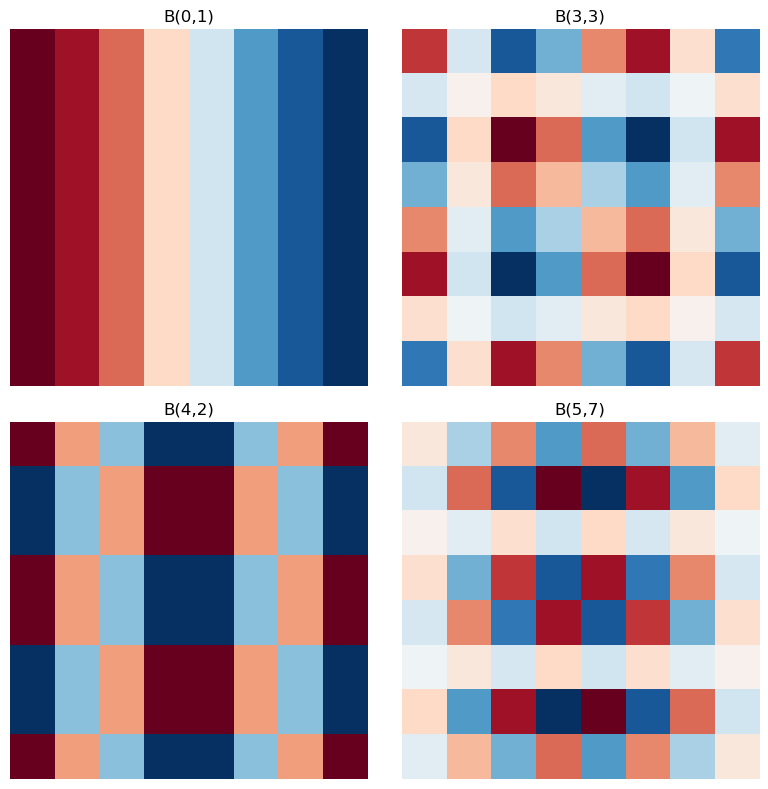

In [36]:
# TODO: construct the 1D DCT basis matrix

def dct_1d_basis_matrix(N):
    Bk = np.zeros((N,N))

    for k in range(N):
        for n in range(N):
            if k == 0:
                ck = np.sqrt(1/N)
            else:
                ck = np.sqrt(2/N)
            
            Bk[k, n] = ck * np.cos((np.pi * k * (2*n + 1))/(2 * N))
    
    return Bk

def dct_2d_basis(C):
    N = C.shape[0]
    B = np.zeros((N, N, N, N))  # (u, v, x, y)

    for u in range(N):
        for v in range(N):
            B[u, v] = np.outer(C[u], C[v])

    return B

print(np.round(dct_1d_basis_matrix(8),3))
B = dct_2d_basis(dct_1d_basis_matrix(8))

examples = [(0,1), (3,3), (4,2), (5,7)]

plt.figure(figsize=(8, 8))

for i, (u, v) in enumerate(examples):
    plt.subplot(2, 2, i+1)
    plt.imshow(B[u, v], cmap='RdBu_r')
    plt.title(f"B({u},{v})")
    plt.axis('off')

plt.tight_layout()
plt.show()
# TODO: construct the 2D 8x8 basis functions
# TODO: visualize at least 4 example basis functions

### Reflection
Use your own basis visualizations as evidence.

- What do low-frequency basis functions represent?
- What do high-frequency basis functions represent?
- Why is it useful that many natural-image blocks can often be represented mainly by low-frequency basis functions?

Write your reflection here.

## D2. Build the intraframe pipeline

## Goal
Compress one frame using transform coding.

## Required components
You must implement:
- RGB → Y conversion
- block splitting
- DCT
- quantization
- Huffman coding of quantized DCT coefficients
- inverse quantization
- inverse DCT
- block merging
- reconstruction
- PSNR

## Hint
Keep your helper functions small and testable.

In [38]:
# TODO: define helper functions for:

# rgb2y
def frameRGB2YUV(RGBframe):
    RGBframe = RGBframe.astype(np.float32)
    RGBframe = RGBframe.astype(np.float32)

    R = RGBframe[:, :, 0]
    G = RGBframe[:, :, 1]
    B = RGBframe[:, :, 2]

    Y = (0.299 * R) + (0.587 * G) + (0.114 * B)
    return Y


# block_split
def block_split(img, block_size=BLOCK_SIZE):
    h, w = img.shape
    blocks = []

    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = img[i:i+block_size, j:j+block_size]
            blocks.append(block)
    return blocks

# block_merge
def block_merge(blocks, image_shape, block_size=BLOCK_SIZE):
    h, w = image_shape
    img = np.zeros((h, w), dtype=np.float32)

    idx = 0
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            img[i:i+block_size, j:j+block_size] = blocks[idx]
            idx += 1

    return img

# dct2
def dct2(x):
    return dct(dct(x, axis=0, norm='ortho'), axis=1, norm='ortho')

# idct2
def idct2(x):
    return idct(idct(x, axis=0, norm='ortho'), axis=1, norm='ortho')

# psnr
def CalculatePSNR(im1, im2):
    if im1.shape != im2.shape:
        raise ValueError("Images must have the same shape.")

    # TODO: convert to float
    im1 = im1.astype(np.float32)
    im2 = im2.astype(np.float32)

    # TODO: compute mean squared error
    mse = np.mean((im1 - im2) ** 2)

    if mse == 0:
        return float("inf")

    # TODO: compute PSNR
    psnr = 10 * np.log10((255**2) / mse)
    return psnr

## D3. Huffman coding requirement

## Goal
Code the quantized DCT coefficients with Huffman coding.

## Minimum steps
- flatten the quantized coefficients
- compute symbol probabilities
- build a Huffman dictionary
- encode the coefficients into a bitstream
- decode the bitstream
- verify exact symbol recovery before reconstruction

## Important
Huffman coding is **lossless**.
Any distortion in the reconstructed image should come from **quantization**, not from Huffman coding.

In [40]:
# TODO: define helper functions for:

# build_symbol_probabilities
def build_symbol_probabilities(data):
    
    flat = data.flatten()
    values, counts = np.unique(flat, return_counts=True)
    total = counts.sum()
    probs = {val: count / total for val, count in zip(values, counts)}
    return probs

# build_huffman_dict
def Huffmandict(p):
    """Generate a Huffman code dictionary from a probability dictionary."""
    heap = [[prob, [symbol, ""]] for symbol, prob in p.items()]
    heapq.heapify(heap)

    if len(heap) == 0:
        return {}
    if len(heap) == 1:
        symbol = heap[0][1][0]
        return {symbol: "0"}

    while len(heap) > 1:
        lo = heapq.heappop(heap)
        hi = heapq.heappop(heap)

        for pair in lo[1:]:
            pair[1] = "0" + pair[1]
        for pair in hi[1:]:
            pair[1] = "1" + pair[1]

        # TODO: push merged node back into the heap
        heapq.heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])

    huff_list = sorted(heap[0][1:], key=lambda pair: (len(pair[1]), str(pair[0])))
    huff_dict = {symbol: codeword for symbol, codeword in huff_list}
    return huff_dict

# huffman_encode
def Huffmanenco(OriginalImage, Huffdict):
    """Perform Huffman encoding on an integer image and return a bitstream string."""
    flat = OriginalImage.flatten()

    # TODO: replace each symbol by its Huffman codeword
    encoded = "".join(Huffdict[symbol] for symbol in flat)
    return encoded

# huffman_decode
def Huffmandeco(EncodedImage, Huffdict, shape):
    """Decode a Huffman bitstream back into an integer image."""
    reverse_dict = {v: k for k, v in Huffdict.items()}

    decoded_symbols = []
    buffer = ""

    for bit in EncodedImage:
        buffer += bit
        if buffer in reverse_dict:
            decoded_symbols.append(reverse_dict[buffer])
            buffer = ""
    decoded = np.array(decoded_symbols).reshape(shape)
    return decoded

# optional: bits_per_symbol or approximate coding rate
def bits_per_symbol(encoded_bitstream, original_data):
    total_bits = len(encoded_bitstream)
    num_symbols = original_data.size
    return total_bits / num_symbols

In [49]:
# TODO: build the intraframe pipeline
# intra_y
intra_y = frameRGB2YUV(intra_rgb)

#blocks
blocks = block_split(intra_y)

#dct_blocks
dct_blocks = [dct2(block) for block in blocks]

#q_blocks
q_blocks = [np.round(b / DEFAULT_Q).astype(int) for b in dct_blocks]

#huff_dict
q_flat = np.concatenate([b.flatten() for b in q_blocks])
huff_dict = Huffmandict(build_symbol_probabilities(q_flat))

# bitstream
bitstream = Huffmanenco(q_flat, huff_dict)

# q_blocks_decoded
decoded_flat = Huffmandeco(bitstream, huff_dict, q_flat.shape)
q_blocks_decoded = []
for i in range(len(q_blocks)):
    q_blocks_decoded.append(decoded_flat[i*64:(i+1)*64].reshape(8,8))


# intra_y_reconstructed
reconstructed_blocks = [idct2(b * DEFAULT_Q) for b in q_blocks_decoded]
intra_y_reconstructed = block_merge(reconstructed_blocks, intra_y.shape)
intra_y_reconstructed = np.clip(intra_y_reconstructed, 0, 255).astype(np.uint8)

# intra_psnr
intra_psnr = CalculatePSNR(intra_y, intra_y_reconstructed)

Huffman lossless check: True


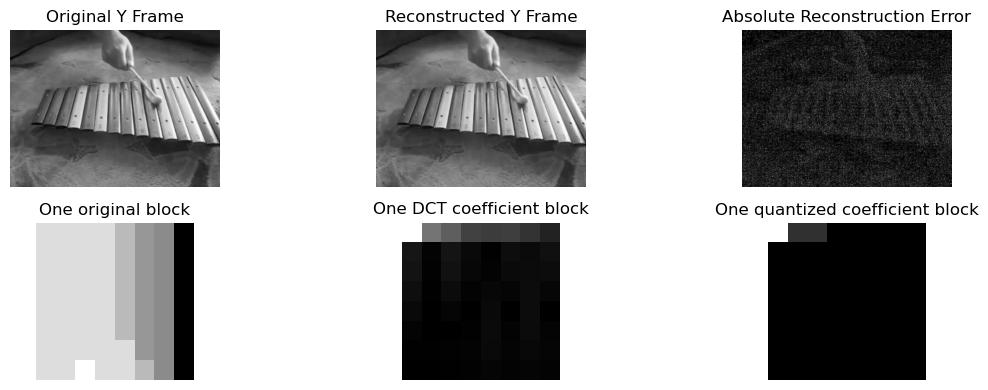

In [59]:
# TODO: show
plt.figure(figsize=(12, 4))

# - original Y frame
plt.subplot(2, 3, 1)
plt.imshow(intra_y, cmap="gray")
plt.title("Original Y Frame")
plt.axis("off")

# - reconstructed Y frame
plt.subplot(2, 3, 2)
plt.imshow(intra_y_reconstructed, cmap="gray")
plt.title("Reconstructed Y Frame")
plt.axis("off")

# - error image
recon_diff = np.abs(intra_y.astype(np.int16) - intra_y_reconstructed.astype(np.int16))
plt.subplot(2, 3, 3)
plt.imshow(recon_diff, cmap="gray")
plt.title("Absolute Reconstruction Error")
plt.axis("off")


# - one original block
plt.subplot(2, 3, 4)
plt.imshow(blocks[5], cmap="gray")
plt.title("One original block")
plt.axis("off")


# - one DCT coefficient block
plt.subplot(2, 3, 5)
plt.imshow(np.log1p(np.abs(dct_blocks[5])), cmap="gray")
plt.title("One DCT coefficient block")
plt.axis("off")


# - one quantized coefficient block
plt.subplot(2, 3, 6)
plt.imshow(np.log1p(np.abs(q_blocks[5])), cmap="gray")
plt.title("One quantized coefficient block")
plt.axis("off")

# - one statement confirming that Huffman decoding recovers the quantized coefficients exactly
recovered_flat = np.concatenate([b.flatten() for b in q_blocks_decoded])
original_flat = np.concatenate([b.flatten() for b in q_blocks])

print("Huffman lossless check:", np.array_equal(recovered_flat, original_flat))

plt.tight_layout()
plt.show()

### Stage 1 analysis

Use your outputs as evidence.

Discuss:
- which coefficients dominate in natural image blocks
- what information is preserved after DCT
- what artifacts appear after quantization
- how Huffman coding helps after quantization
- why Huffman coding does not itself create distortion

Write your Stage 1 analysis here.

# E. Stage 2 — Predictive compression

This stage extends your system to temporal compression.

## E1. Choose and describe your prediction method

## Goal
Define how you predict the target frame from the reference frame.

## Allowed options
- simple frame differencing
- block matching or motion-based prediction

## Deliverable
Write 3–5 clear sentences explaining:
- what you predict
- how you compute the residual
- what assumptions your method makes

Write your prediction method description here.

## E2. Critical rule: DPCM principle

When performing frame prediction, you must always use the **reconstructed previous frame**, not the original previous frame, to predict the current frame.

This is essential.

If your system uses temporal prediction, then:
- the encoder predicts from the reconstructed previous frame
- the decoder does the same

This prevents mismatch and follows the DPCM principle.

## E3. Build the predictive pipeline

## Goal
Compress the residual using your intraframe machinery.

## Required components
- reference frame
- target frame
- prediction
- residual
- transform and quantization of residual
- Huffman coding of quantized residual coefficients
- residual reconstruction
- target reconstruction
- PSNR

## Minimum deliverable
Show:
- reference frame
- target frame
- predicted frame
- residual visualization
- reconstructed target frame
- reconstruction error

In [12]:
# TODO: implement predictive coding with the DPCM principle
# Suggested outputs:
# ref_y, target_y, pred_y, residual
# residual_dct, residual_q
# residual_huff_dict, residual_bitstream
# residual_q_decoded
# target_y_reconstructed, target_psnr

In [13]:
# TODO: visualize
# - reference frame
# - target frame
# - predicted frame
# - residual
# - reconstructed target frame
# - reconstruction error

### Stage 2 analysis

Use your outputs as evidence.

Discuss:
- why the residual is often easier to compress
- what assumptions your prediction method makes
- when the prediction fails
- why the DPCM principle matters
- what role Huffman coding plays for the residual

Write your Stage 2 analysis here.

# F. Stage 3 — System evaluation and experiments

This is the most important stage.

You must complete **two required experiments**.

## F1. Experiment 1 — Quantization study

## Goal
Study how quantization changes quality and coding behavior.

## Requirement
Test at least **three** quantization settings.

For each setting, report:
- PSNR
- one compression-related measure
- one visual observation

### Acceptable compression-related measures
- entropy of quantized coefficients
- percentage of zero coefficients
- approximate coding rate
- Huffman rate

## Minimum deliverable
At least:
- one plot of quantization level vs PSNR
- one additional comparison, for example:
  - quantization level vs Huffman rate
  - quantization level vs zero coefficient ratio
  - quantization level vs entropy

In [14]:
# TODO: run Experiment 1
# Suggested metrics:
# - PSNR
# - entropy of quantized coefficients
# - zero coefficient ratio
# - Huffman rate

In [15]:
# TODO: plot quantization level vs PSNR
# TODO: plot one additional comparison

### Experiment 1 discussion

Use your own plots as evidence.

Explain:
- how quantization affects low and high frequencies
- why stronger quantization changes visual quality
- what trade-off you observe

Write your Experiment 1 discussion here.

## F2. Experiment 2 — Whole-video compression experiment

## Goal
Evaluate your system over time.

## Requirement
Apply your system to the whole video, or at least a continuous segment of **30 or more frames**.

## Required outputs
Report:
- average PSNR over time
- one compression-related measure over time
- one plot of frame index vs PSNR
- one short discussion of temporal behavior

## Important reminder
When performing frame prediction, always use the **reconstructed previous frame**, not the original previous frame, to predict the current frame.

### Recommended whole-video algorithm skeleton

A safe structure is:

- frame 0: intraframe compression
- frame 1, 2, 3, ...:
  - predict from the reconstructed previous frame
  - compute residual
  - compress the residual
  - reconstruct the current frame
  - store the reconstructed current frame for the next prediction

This is where many projects fail, so be explicit in your implementation.

In [16]:
# TODO: run Experiment 2 on the whole video (or 30+ consecutive frames)
# Suggested outputs:
# - list of frame-wise PSNR values
# - average PSNR
# - list of frame-wise Huffman rates or entropy values
# - explicit use of reconstructed previous frame for prediction

In [17]:
# TODO: plot frame index vs PSNR
# TODO: plot one compression-related measure over time

### Experiment 2 discussion

Use your own results as evidence.

Explain:
- whether quality remains stable over time
- whether error accumulation appears
- whether your prediction method behaves differently in different scenes
- whether the DPCM principle matters in practice

Write your Experiment 2 discussion here.

## F3. Optional third experiment

Students aiming for stronger projects may add one extra experiment, for example:
- intraframe vs predictive coding comparison
- residual statistics before and after prediction
- different block sizes
- different quantization strategies
- simple difference vs block matching
- rate–distortion comparison

In [18]:
# Optional: add a third experiment here

# G. Final analysis

Your notebook must answer these questions clearly.

Use your own results as evidence whenever possible.

## A. DCT and representation
- What is the role of DCT in compression?
- Why are low-frequency components often more important than high-frequency components?

## B. Quantization
- How does quantization affect different frequencies?
- Why does quantization introduce distortion?

## C. Prediction
- Why does predictive coding often improve efficiency?
- Why must the reconstructed previous frame be used instead of the original previous frame?

## D. System behavior
- What are the limitations of your system?
- What trade-offs did you observe between quality, coding rate, and complexity?
- How did your system behave over time on the whole video?

Write your final analysis here.

# H. Expected checkpoints

Use these checkpoints to keep your project on track.

### Checkpoint 1
Intraframe pipeline works on one frame.

Expected evidence:
- reconstructed frame
- PSNR
- DCT basis visualization
- Huffman coding of quantized DCT coefficients works

### Checkpoint 2
Predictive coding works on two frames.

Expected evidence:
- residual
- reconstructed target frame
- PSNR
- Huffman coding of residual quantized coefficients works

### Checkpoint 3
Quantization experiment completed.

Expected evidence:
- at least 3 settings
- PSNR plot
- one compression-related plot

### Checkpoint 4
Whole-video evaluation completed.

Expected evidence:
- at least 30 frames processed
- average PSNR
- frame-wise plot
- discussion of temporal behavior

# I. Final comparison summary

Summarize your system in a compact form.

## Include
- your intraframe method
- your prediction method
- whether Huffman coding helped and how
- how you applied your method to the whole video
- your best quantitative result
- one key temporal observation
- your main qualitative insight

Write your final summary here.

# J. Group work and individual reflection

Each student must submit individually.

Include:
- names of group members
- what you understood best
- what you found difficult
- a short individual reflection of about half a page

### Group members
Erik Esshagen & Nora Sennerö

### What I understood best
Write here.

### What I found difficult
Write here.

### Individual reflection
Write here.

# K. Final checklist

Before submission, check:

- [ ] the notebook runs from top to bottom
- [ ] all required sections are completed
- [ ] DCT basis functions are constructed and visualized
- [ ] Huffman coding is used to code quantized DCT coefficients
- [ ] intraframe pipeline works
- [ ] predictive pipeline works
- [ ] the DPCM principle is used correctly
- [ ] quantization study is included
- [ ] whole-video experiment is included
- [ ] analysis and reflection are written
- [ ] code is clean and readable